In [18]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/enh2134/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


In [4]:
ds = xr.open_dataset(
    '/home/enh2134/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc', engine="netcdf4")
print(ds.variables)

Frozen({'lon': <xarray.IndexVariable 'lon' (lon: 360)> Size: 1kB
array([  0.5,   1.5,   2.5, ..., 357.5, 358.5, 359.5], dtype=float32)
Attributes:
    long_name:      longitude
    standard_name:  longitude
    units:          degrees_east
    valid_range:    [  0. 360.], 'toa_sw_all_mon': <xarray.Variable (time: 203, lat: 180, lon: 360)> Size: 53MB
[13154400 values with dtype=float32]
Attributes:
    long_name:      Top of The Atmosphere Shortwave Flux, Monthly Means, All-...
    standard_name:  TOA Shortwave Flux - All-Sky
    CF_name:        toa_outgoing_shortwave_flux
    units:          W m-2
    valid_min:            0.00000
    valid_max:            600.000, 'toa_lw_all_mon': <xarray.Variable (time: 203, lat: 180, lon: 360)> Size: 53MB
[13154400 values with dtype=float32]
Attributes:
    long_name:      Top of The Atmosphere Longwave Flux, Monthly Means, All-S...
    standard_name:  TOA Longwave Flux - All-Sky
    CF_name:        toa_outgoing_longwave_flux
    units:          W 

In [6]:
for name, var in ds.variables.items():
    long_name = var.attrs.get('long_name')
    print(long_name)

longitude
Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
Incoming Solar Flux, Monthly Means
Cloud Area Fraction, Monthly Means, Daytime-and-Nighttime conditions
Cloud Effective Pressure, Monthly Means, Daytime-and-Nighttime conditions
Cloud Effective Temperature, Monthly Means, Daytime-and-Nighttime conditions
Cloud Visible Optical Depth, Monthly Means, Daytime conditions
time
latitude


In [7]:
ds_mean =  ds.mean(dim='time')
print(ds_mean)

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 5

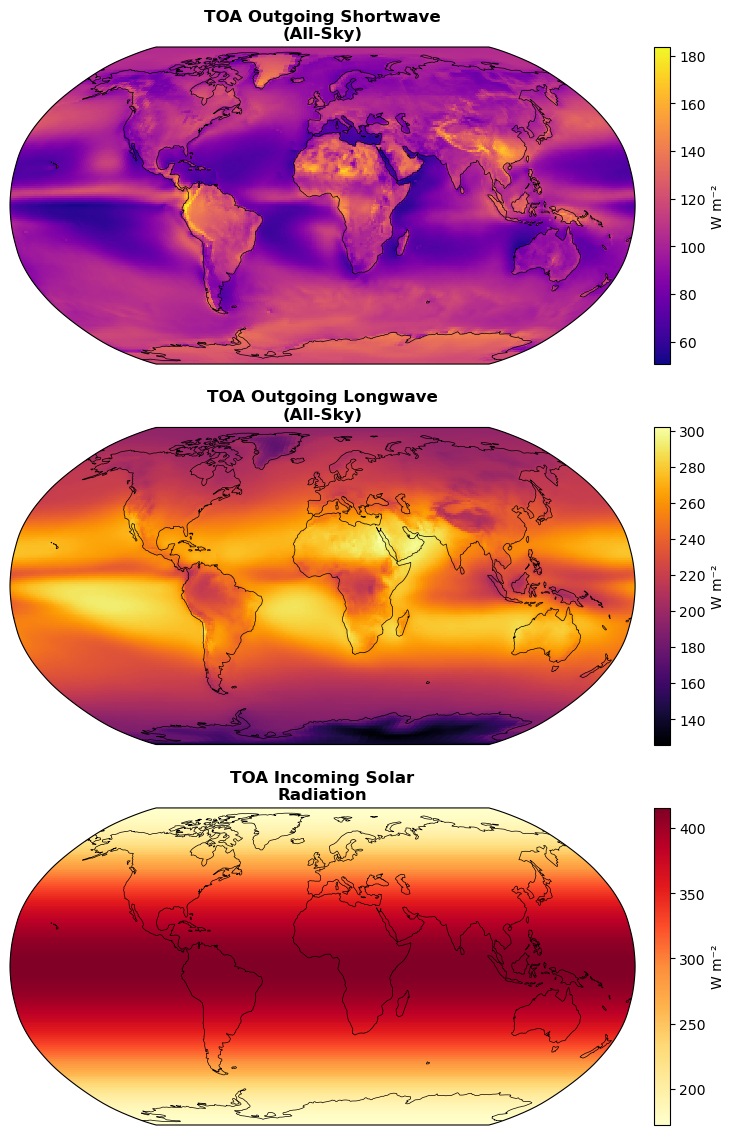

In [8]:
variables = {
    'toa_sw_all_mon': ('TOA Outgoing Shortwave\n(All-Sky)', 'W m⁻²', 'plasma'),
    'toa_lw_all_mon': ('TOA Outgoing Longwave\n(All-Sky)', 'W m⁻²', 'inferno'),
    'solar_mon':      ('TOA Incoming Solar\nRadiation', 'W m⁻²', 'YlOrRd'),
}

fig, axes = plt.subplots(3, 1, figsize=(12, 14),
                         subplot_kw={'projection': ccrs.Robinson()})

for ax, (var, (title, units, cmap)) in zip(axes, variables.items()):
    data = ds_mean[var]
    
    im = ax.pcolormesh(
        ds_mean.lon, ds_mean.lat, data,
        transform=ccrs.PlateCarree(),
        cmap=cmap
    )
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, fraction=0.02)
    cbar.set_label(units, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')

Text(0.5, 1.0, 'Total Net Flux Estimated')

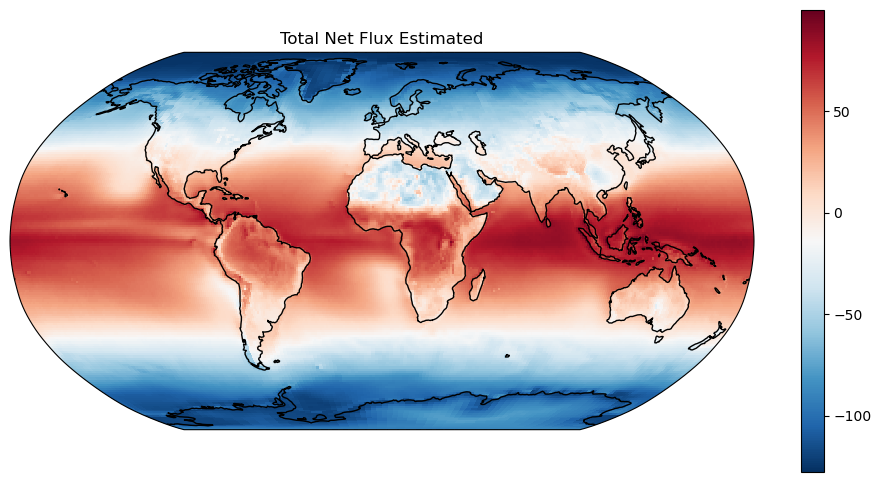

In [7]:
toa_net = ds_mean['solar_mon'] - ds_mean['toa_sw_all_mon'] - ds_mean['toa_lw_all_mon']
fig,ax = plt.subplots(1,1,
                      subplot_kw={'projection': ccrs.Robinson()})
im =ax.pcolormesh(
    ds_mean.lon, ds_mean.lat, toa_net, transform = ccrs.PlateCarree(),cmap='RdBu_r')
ax.add_feature(cfeature.COASTLINE)
cbar= plt.colorbar(im, ax=ax)
ax.set_title('Total Net Flux Estimated')

Text(0.5, 1.0, 'Total Net Flux Observations')

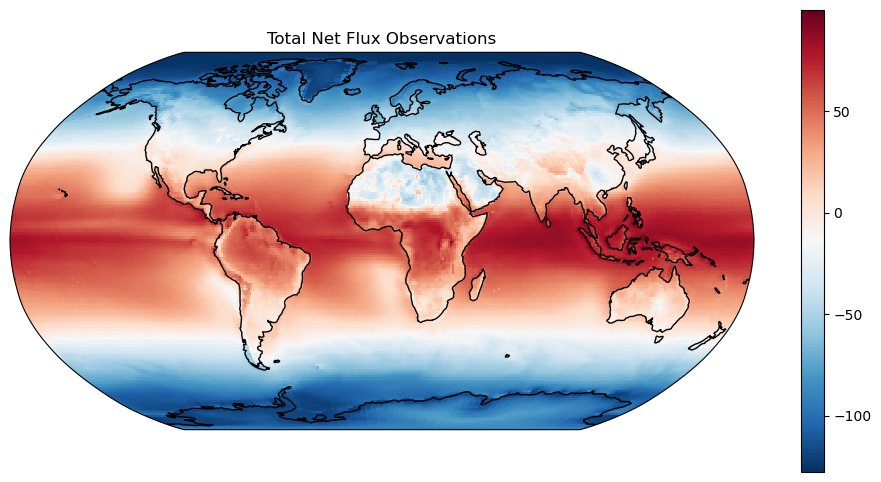

In [8]:
fig,ax = plt.subplots(1,1,
                      subplot_kw={'projection': ccrs.Robinson()})
im =ax.pcolormesh(
    ds_mean.lon, ds_mean.lat, ds_mean['toa_net_all_mon'], transform = ccrs.PlateCarree(),cmap='RdBu_r')
ax.add_feature(cfeature.COASTLINE)
cbar= plt.colorbar(im, ax=ax)
ax.set_title('Total Net Flux Observations')

# 3) Mean and Weighted mean

In [9]:
mean_unweighted = ds.mean(dim=('lat','lon'))
mean_unweighted.toa_net_all_mon.mean()

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(-28.729012, dtype=float32)

In [10]:
weights = np.cos(ds.lat*np.pi/180)

In [11]:
mean_weighted = ds.weighted(weights).mean(dim=('lat','lon'))
mean_weighted.toa_net_all_mon.mean()

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(0.87808716, dtype=float32)

Since global warming is an internal forcing, it is harder to detect from energy and energy out, since those factors are more effected by external forcing, such as variations in solar strength. 

 Now that you have a weight factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment

In [12]:
print('Short Wave:', mean_weighted.toa_sw_all_mon.mean())
print('Long Wave:', mean_weighted.toa_lw_all_mon.mean())
print('Total Shortwave Radiation', mean_weighted.solar_mon.mean())

Short Wave: <xarray.DataArray 'toa_sw_all_mon' ()> Size: 4B
array(99.138565, dtype=float32)
Long Wave: <xarray.DataArray 'toa_lw_all_mon' ()> Size: 4B
array(240.26683, dtype=float32)
Total Shortwave Radiation <xarray.DataArray 'solar_mon' ()> Size: 4B
array(340.28348, dtype=float32)


# 4) Meridional Heat Transport Calculation

In [13]:
dlambda = np.deg2rad(1)
dphi = np.deg2rad(1)

In [14]:
pixel = np.cos(ds.lat*np.pi/180)*(6371**2)* xr.ones_like(ds_mean.toa_net_all_mon)*dlambda*dphi
pixel

<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[107.89792584, 107.89792584, 107.89792584, ..., 107.89792584,
        107.89792584, 107.89792584],
       [323.66052173, 323.66052173, 323.66052173, ..., 323.66052173,
        323.66052173, 323.66052173],
       [539.32305085, 539.32305085, 539.32305085, ..., 539.32305085,
        539.32305085, 539.32305085],
       ...,
       [539.32305085, 539.32305085, 539.32305085, ..., 539.32305085,
        539.32305085, 539.32305085],
       [323.66052173, 323.66052173, 323.66052173, ..., 323.66052173,
        323.66052173, 323.66052173],
       [107.89792584, 107.89792584, 107.89792584, ..., 107.89792584,
        107.89792584, 107.89792584]])
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

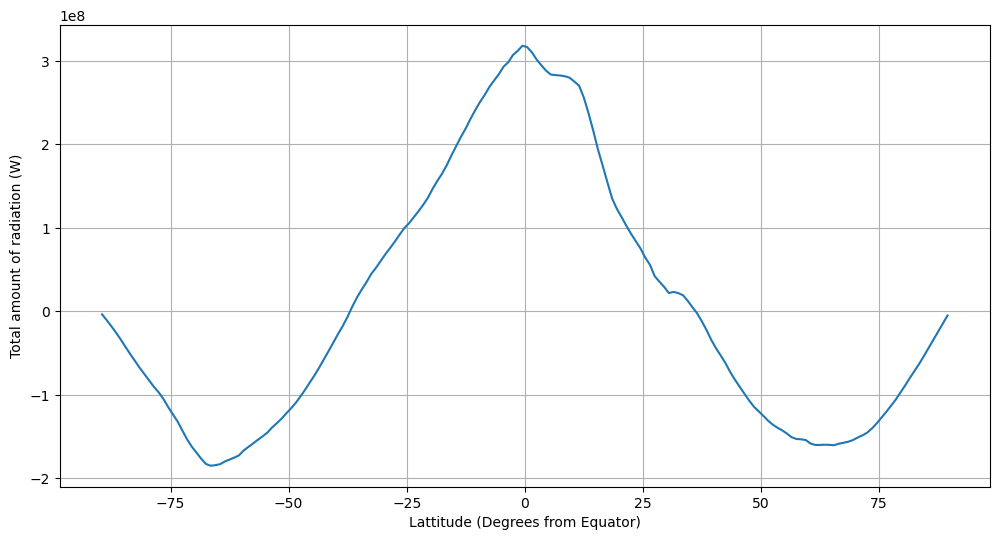

In [15]:
netrad = pixel*ds_mean.toa_net_all_mon
netrad_Lat = netrad.sum(dim='lon')
netrad_Lat.plot()
plt.ylabel('Total amount of radiation (W)')
plt.xlabel('Lattitude (Degrees from Equator)')
plt.grid(True)

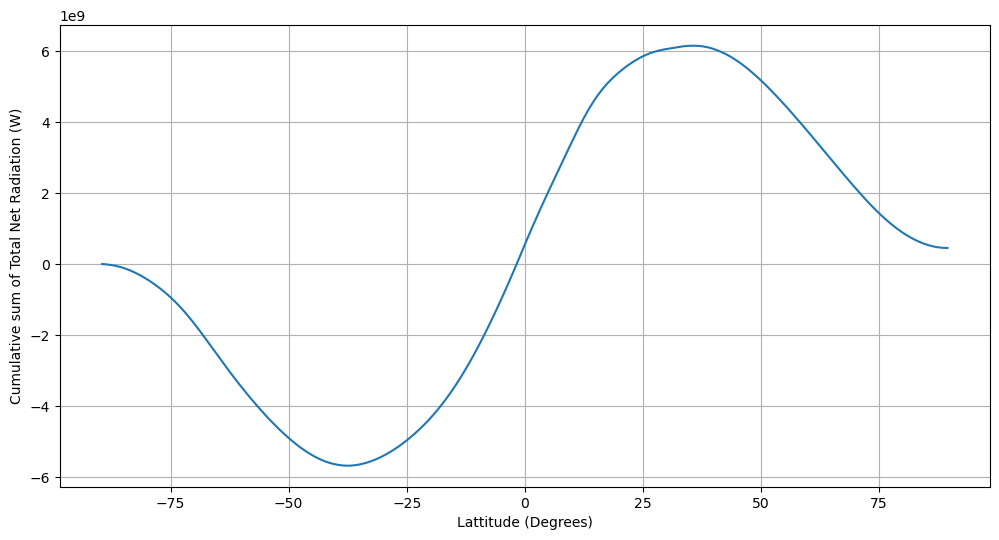

In [16]:
CumRad = pixel*ds_mean.toa_net_all_mon
CumRad_Lat = CumRad.sum(dim='lon').cumsum()
CumRad_Lat.plot()
plt.ylabel('Cumulative sum of Total Net Radiation (W)')
plt.xlabel('Lattitude (Degrees)')
plt.grid(True)

## Making Maps with Cartopy

### 5.2 Antarctic Sea Ice

In [7]:
import xarray as xr
import pooch
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')

In [3]:
import cartopy
import cartopy.crs as ccrs

In [2]:
print(ds_ice)

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:             

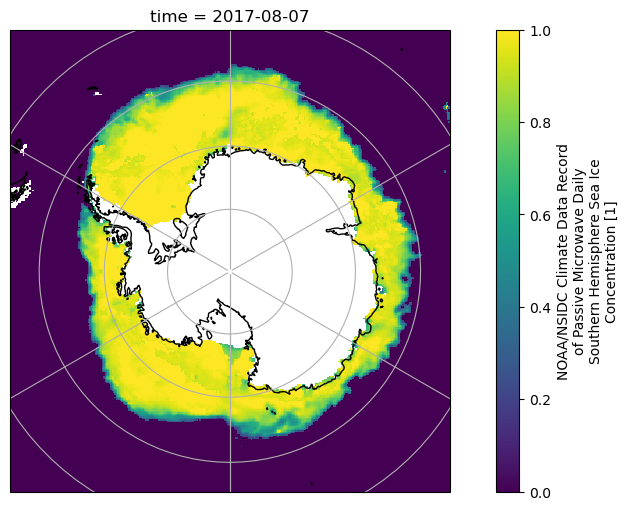

In [15]:
ice_conc = ds_ice.where(ds_ice.seaice_conc_cdr <= 1)
mapice = ice_conc.seaice_conc_cdr.sel(time = '2017-08-07')
ax = plt.axes(projection=ccrs.SouthPolarStereo())
mapice.plot(vmin=0, vmax=1)
plt.title('time = 2017-08-07')
ax.gridlines()
ax.coastlines()

In [19]:
import pandas as pd

In [36]:
url = 'http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv'
df = pd.read_csv(url, parse_dates=['time','updated'], index_col = 'id')
df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.252000,-152.708100,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05 19:34:41.515000+00:00,"26km S of Redoubt Volcano, Alaska",earthquake
nn00436847,2014-01-31 23:48:35.452,37.070300,-115.130900,0.00,1.33,ml,4.0,171.43,0.342000,0.0247,nn,2014-02-01 01:35:09+00:00,"32km S of Alamo, Nevada",earthquake
ak11151142,2014-01-31 23:47:24.000,64.671700,-149.252800,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01 00:03:53.010000+00:00,"12km NNW of North Nenana, Alaska",earthquake
ak11151135,2014-01-31 23:30:54.000,63.188700,-148.957500,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31 23:41:25.007000+00:00,"22km S of Cantwell, Alaska",earthquake
ci37171541,2014-01-31 23:30:52.210,32.616833,-115.692500,10.59,1.34,ml,6.0,285.00,0.043210,0.2000,ci,2014-02-01 00:13:20.107000+00:00,"10km WNW of Progreso, Mexico",earthquake
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ak11453391,2014-12-01 00:10:16.000,60.963900,-146.762900,14.80,3.80,ml,NaN,NaN,NaN,0.6900,ak,2015-03-24 18:25:07.628000+00:00,"29km SW of Valdez, Alaska",earthquake
ak11453395,2014-12-01 00:09:39.000,58.869100,-154.415900,108.40,2.40,ml,NaN,NaN,NaN,0.6700,ak,2014-12-10 01:04:25.209000+00:00,"102km SSE of Old Iliamna, Alaska",earthquake
nc72358451,2014-12-01 00:09:25.350,38.843498,-122.825836,2.37,0.43,md,8.0,107.00,0.008991,0.0300,nc,2014-12-01 01:15:02.814000+00:00,"9km WNW of Cobb, California",earthquake


In [52]:
top50 = df.sort_values('mag', ascending = False).head(50)
lat = top50['latitude']
lon = top50['longitude']
mag = top50['mag']

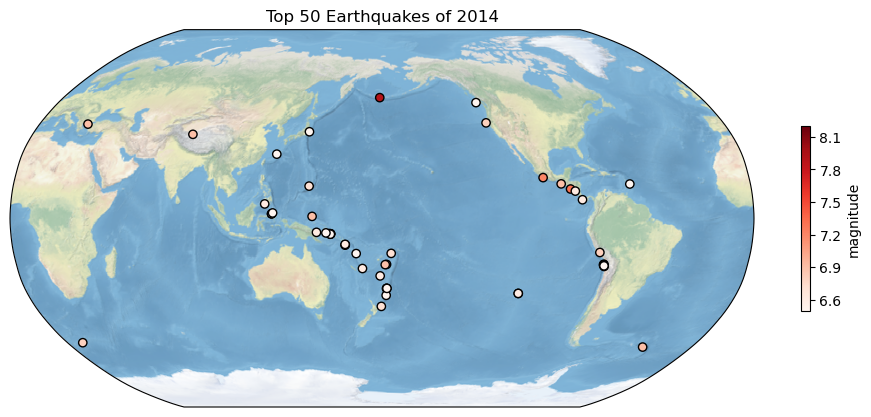

In [59]:
Robinson = ccrs.Robinson(central_longitude = 180)
ax = plt.axes(projection = Robinson)
ax.stock_img()
plt.title('Top 50 Earthquakes of 2014')
map = ax.scatter(lon, lat, c=mag, cmap='Reds',
          transform=ccrs.PlateCarree(),
          edgecolors='black')
plt.colorbar(map, label='magnitude', shrink=0.4, ticks =np.arange(6.6,8.4,0.3))